In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/classification_clean.zip"
extract_path = "/content/smartvision_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print(os.listdir(extract_path))

Dataset extracted successfully!
['classification_clean']


In [9]:
import os

for root, dirs, files in os.walk("/content/smartvision_data"):
    level = root.replace("/content/smartvision_data", "").count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

smartvision_data/
  classification_clean/
    train/
    val/
    test/


## 1. Dataset Verification

Load the leakage-free SmartVision dataset from Google Drive and verify the number of images in the training, validation, and test sets.

In [10]:
from pathlib import Path

DATASET_DIR = Path("/content/smartvision_data/classification_clean")

for split in ["train", "val", "test"]:
    split_dir = DATASET_DIR / split

    total = sum(
        1 for p in split_dir.rglob("*")
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}
    )

    print(f"{split}: {total} images")

train: 3278 images
val: 692 images
test: 729 images


## 2. Model Development

The leakage-free dataset has been verified and is ready for CNN classification.

We will use PyTorch and transfer learning to train an image classification model for 26 classes.

In [16]:
# Core libraries
import torch
import torch.nn as nn
import torch.optim as optim

# Dataset and DataLoader
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Model architectures
from torchvision import models

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt

# Utilities
import numpy as np
from pathlib import Path

In [4]:
# Check device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 3. Transfer Learning with VGG16

A pretrained VGG16 model will be used for image classification.

The pretrained convolutional layers provide general visual features learned from ImageNet.

The final classifier will be modified to predict the 26 SmartVision classes.

In [13]:
# Load pretrained VGG16

weights = models.VGG16_Weights.DEFAULT

model = models.vgg16(weights=weights)

# Replace the final classification layer
num_features = model.classifier[6].in_features

model.classifier[6] = nn.Linear(num_features, 26)

# Move model to GPU
model = model.to(device)

print(model.classifier[6])

Linear(in_features=4096, out_features=26, bias=True)


### 3.1 VGG16 Input Preprocessing

VGG16 was pretrained using ImageNet images. Therefore, the input images must be normalized using the ImageNet mean and standard deviation.

Augmentation is applied only to the training set.
Validation and test sets use resizing and normalization without augmentation.

In [17]:
# ImageNet normalization

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

print("VGG16 preprocessing pipeline created.")

VGG16 preprocessing pipeline created.


In [18]:
# Apply the VGG16 preprocessing

train_dataset = datasets.ImageFolder(
    DATASET_DIR / "train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    DATASET_DIR / "val",
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    DATASET_DIR / "test",
    transform=val_test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))
print("Classes:", len(train_dataset.classes))

Train: 3278
Validation: 692
Test: 729
Classes: 26


### 3.2 Create DataLoaders

Create batch-based DataLoaders for training, validation, and testing.

The training data is shuffled, while validation and test data are kept in a fixed order.

In [19]:
# Create DataLoaders

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 26
Validation batches: 6
Test batches: 6


### 3.3 Freeze VGG16 Feature Extractor

The pretrained VGG16 convolutional layers already contain useful visual features.

Initially, these layers will be frozen so that only the newly replaced 26-class classifier is trained.

In [20]:
# Freeze pretrained VGG16 feature layers

for param in model.features.parameters():
    param.requires_grad = False

# Check trainable parameters
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel() for p in model.parameters()
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 134367066
Trainable parameters: 119652378


### 3.4 Class-Weighted Loss

The training dataset contains different numbers of images across the 26 classes.

Class weights will be calculated from the training set and supplied to CrossEntropyLoss so that errors on underrepresented classes receive greater importance.

In [21]:
from collections import Counter

# Count samples for each class
train_class_counts = Counter(train_dataset.targets)

num_classes = len(train_dataset.classes)
total_samples = len(train_dataset)

# Calculate class weights
class_weights = torch.tensor(
    [
        total_samples / (num_classes * train_class_counts[i])
        for i in range(num_classes)
    ],
    dtype=torch.float32
).to(device)

print("Class counts:")
print(train_class_counts)

print("\nClass weights:")
print(class_weights)

Class counts:
Counter({10: 218, 1: 212, 12: 195, 24: 189, 15: 174, 22: 163, 7: 161, 25: 156, 0: 145, 20: 137, 2: 133, 21: 132, 6: 125, 14: 115, 18: 110, 8: 104, 17: 103, 3: 102, 16: 100, 5: 88, 23: 85, 11: 72, 4: 69, 13: 68, 9: 66, 19: 56})

Class weights:
tensor([0.8695, 0.5947, 0.9479, 1.2360, 1.8272, 1.4327, 1.0086, 0.7831, 1.2123,
        1.9103, 0.5783, 1.7511, 0.6465, 1.8541, 1.0963, 0.7246, 1.2608, 1.2240,
        1.1462, 2.2514, 0.9203, 0.9551, 0.7735, 1.4833, 0.6671, 0.8082],
       device='cuda:0')


In [22]:
# Weighted CrossEntropyLoss

criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Class-weighted CrossEntropyLoss created.")

Class-weighted CrossEntropyLoss created.


In [23]:
# Optimizer for trainable parameters only

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

print("Optimizer created.")

Optimizer created.


### 3.5 Model Training with Early Stopping

The VGG16 model will be trained for a maximum of 200 epochs.

Early stopping will terminate training when the validation loss does not improve for a specified number of consecutive epochs.

The model with the lowest validation loss will be saved as the best model.

In [ ]:
# Training configuration

MAX_EPOCHS = 200
PATIENCE = 10

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "best_vgg16_smartvision.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: best_vgg16_smartvision.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("best_vgg16_smartvision.pth")

print("✅ Download requested successfully!")

Epoch [1/200] | Train Loss: 2.7464 | Train Acc: 0.2685 | Val Loss: 1.8739 | Val Acc: 0.5231 | ✓ Best model saved
Epoch [2/200] | Train Loss: 1.8042 | Train Acc: 0.4948 | Val Loss: 1.5416 | Val Acc: 0.5910 | ✓ Best model saved
Epoch [3/200] | Train Loss: 1.5003 | Train Acc: 0.5561 | Val Loss: 1.4459 | Val Acc: 0.5997 | ✓ Best model saved
Epoch [4/200] | Train Loss: 1.2976 | Train Acc: 0.6153 | Val Loss: 1.4205 | Val Acc: 0.5939 | ✓ Best model saved
Epoch [5/200] | Train Loss: 1.1366 | Train Acc: 0.6541 | Val Loss: 1.4417 | Val Acc: 0.5896 | Patience: 1/10
Epoch [6/200] | Train Loss: 1.0273 | Train Acc: 0.6864 | Val Loss: 1.4257 | Val Acc: 0.6171 | Patience: 2/10
Epoch [7/200] | Train Loss: 0.9278 | Train Acc: 0.7245 | Val Loss: 1.4191 | Val Acc: 0.6272 | ✓ Best model saved
Epoch [8/200] | Train Loss: 0.7921 | Train Acc: 0.7611 | Val Loss: 1.4589 | Val Acc: 0.6127 | Patience: 1/10
Epoch [9/200] | Train Loss: 0.7175 | Train Acc: 0.7819 | Val Loss: 1.5644 | Val Acc: 0.6127 | Patience: 2/10

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download requested successfully!


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source = "/content/best_vgg16_smartvision.pth"
destination = "/content/drive/MyDrive/best_vgg16_smartvision.pth"

shutil.copy2(source, destination)

print("✅ Model copied to Google Drive!")
print(f"📁 {destination}")
print(f"📦 Size: {os.path.getsize(source) / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive!
📁 /content/drive/MyDrive/best_vgg16_smartvision.pth
📦 Size: 512.58 MB


### 3.6 Training and Validation Performance

The training history is visualized to identify learning behavior and detect overfitting.

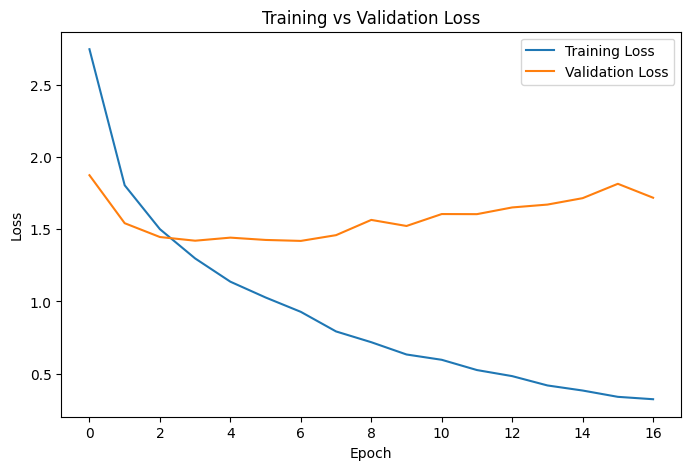

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

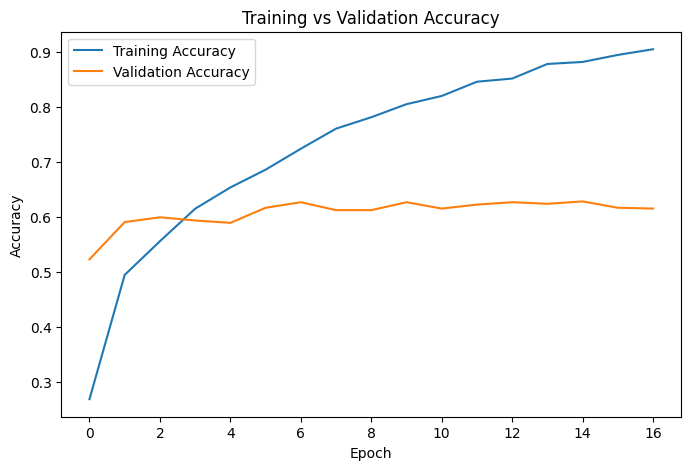

In [ ]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### 3.7 VGG16 with a Lightweight Classifier

The first VGG16 experiment showed strong overfitting because the original VGG16 classifier contains a very large number of trainable parameters.

To reduce overfitting, the pretrained VGG16 feature extractor will be retained while the original classifier is replaced with a smaller classifier containing dropout.

In [ ]:
# Create a fresh pretrained VGG16 model

weights = models.VGG16_Weights.DEFAULT

model = models.vgg16(weights=weights)

# Freeze pretrained convolutional features
for param in model.features.parameters():
    param.requires_grad = False

# Replace the large VGG16 classifier
model.classifier = nn.Sequential(
    nn.Linear(25088, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 26)
)

# Move model to GPU
model = model.to(device)

# Check parameters
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 27573594
Trainable parameters: 12858906


In [ ]:
# Class-weighted loss

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Optimizer for trainable parameters only

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

print("Loss function and optimizer ready.")

Loss function and optimizer ready.


In [ ]:
# Training configuration

MAX_EPOCHS = 200
PATIENCE = 10

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "best_vgg16_light_classifier.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: best_vgg16_light_classifier.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("best_vgg16_light_classifier.pth")

print("✅ Download requested successfully!")

Epoch [1/200] | Train Loss: 2.7248 | Train Acc: 0.2797 | Val Loss: 2.0097 | Val Acc: 0.4913 | ✓ Best model saved
Epoch [2/200] | Train Loss: 1.8716 | Train Acc: 0.4939 | Val Loss: 1.6527 | Val Acc: 0.5448 | ✓ Best model saved
Epoch [3/200] | Train Loss: 1.5771 | Train Acc: 0.5610 | Val Loss: 1.5688 | Val Acc: 0.5853 | ✓ Best model saved
Epoch [4/200] | Train Loss: 1.3624 | Train Acc: 0.6153 | Val Loss: 1.5110 | Val Acc: 0.5809 | ✓ Best model saved
Epoch [5/200] | Train Loss: 1.1932 | Train Acc: 0.6666 | Val Loss: 1.5010 | Val Acc: 0.5780 | ✓ Best model saved
Epoch [6/200] | Train Loss: 1.0730 | Train Acc: 0.7087 | Val Loss: 1.5004 | Val Acc: 0.5795 | ✓ Best model saved
Epoch [7/200] | Train Loss: 0.9842 | Train Acc: 0.7270 | Val Loss: 1.4801 | Val Acc: 0.6098 | ✓ Best model saved
Epoch [8/200] | Train Loss: 0.8982 | Train Acc: 0.7559 | Val Loss: 1.4951 | Val Acc: 0.6069 | Patience: 1/10
Epoch [9/200] | Train Loss: 0.8267 | Train Acc: 0.7807 | Val Loss: 1.5026 | Val Acc: 0.6069 | Patien

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download requested successfully!


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source = "/content/best_vgg16_light_classifier.pth"
destination = "/content/drive/MyDrive/best_vgg16_light_classifier.pth"

shutil.copy2(source, destination)

print("✅ Model copied to Google Drive!")
print(f"📁 {destination}")
print(f"📦 Size: {os.path.getsize(source) / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive!
📁 /content/drive/MyDrive/best_vgg16_light_classifier.pth
📦 Size: 105.20 MB


## 3.8 ResNet18 Transfer Learning

The previous VGG16 experiments showed significant overfitting on the relatively small SmartVision dataset.

ResNet18 will be evaluated as an alternative pretrained CNN architecture.

A pretrained ResNet18 model will be used, and its final classification layer will be replaced to predict the 26 SmartVision classes.

In [ ]:
# Load pretrained ResNet18

weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

# Freeze pretrained feature layers
for param in model.parameters():
    param.requires_grad = False

# Replace the final classification layer
num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 26)

# Move model to GPU
model = model.to(device)

# Check parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Final layer:", model.fc)

Total parameters: 11189850
Trainable parameters: 13338
Final layer: Linear(in_features=512, out_features=26, bias=True)


### 3.9 Loss Function and Optimizer

Class-weighted CrossEntropyLoss is used to give greater importance to underrepresented classes.

The Adam optimizer updates only the trainable final classification layer while the pretrained ResNet18 feature layers remain frozen.

In [ ]:
# Create class-weighted loss

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Optimizer for trainable parameters only

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


### 3.10 ResNet18 Training with Early Stopping

The ResNet18 model will be trained for a maximum of 200 epochs.

Early stopping will stop training when validation loss does not improve for 10 consecutive epochs.

The model with the lowest validation loss will be saved as the best model.

In [ ]:
# Restnet exp 1

MAX_EPOCHS = 200
PATIENCE = 10

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "best_resnet18_smartvision.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: best_resnet18_smartvision.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("best_resnet18_smartvision.pth")

print("✅ Download requested successfully!")

Epoch [1/200] | Train Loss: 3.3371 | Train Acc: 0.0473 | Val Loss: 3.2797 | Val Acc: 0.0592 | ✓ Best model saved
Epoch [2/200] | Train Loss: 3.2241 | Train Acc: 0.0650 | Val Loss: 3.2066 | Val Acc: 0.0780 | ✓ Best model saved
Epoch [3/200] | Train Loss: 3.1654 | Train Acc: 0.0915 | Val Loss: 3.1365 | Val Acc: 0.1098 | ✓ Best model saved
Epoch [4/200] | Train Loss: 3.0955 | Train Acc: 0.1205 | Val Loss: 3.0712 | Val Acc: 0.1402 | ✓ Best model saved
Epoch [5/200] | Train Loss: 3.0258 | Train Acc: 0.1470 | Val Loss: 3.0095 | Val Acc: 0.1691 | ✓ Best model saved
Epoch [6/200] | Train Loss: 2.9769 | Train Acc: 0.1836 | Val Loss: 2.9489 | Val Acc: 0.2038 | ✓ Best model saved
Epoch [7/200] | Train Loss: 2.9195 | Train Acc: 0.2090 | Val Loss: 2.8919 | Val Acc: 0.2283 | ✓ Best model saved
Epoch [8/200] | Train Loss: 2.8568 | Train Acc: 0.2468 | Val Loss: 2.8392 | Val Acc: 0.2529 | ✓ Best model saved
Epoch [9/200] | Train Loss: 2.8028 | Train Acc: 0.2773 | Val Loss: 2.7818 | Val Acc: 0.2890 | ✓ 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download requested successfully!


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source = "/content/best_resnet18_smartvision.pth"
destination = "/content/drive/MyDrive/best_resnet18_smartvision.pth"

shutil.copy2(source, destination)

print("✅ Model copied to Google Drive!")
print(f"📁 {destination}")
print(f"📦 Size: {os.path.getsize(source) / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive!
📁 /content/drive/MyDrive/best_resnet18_smartvision.pth
📦 Size: 42.76 MB


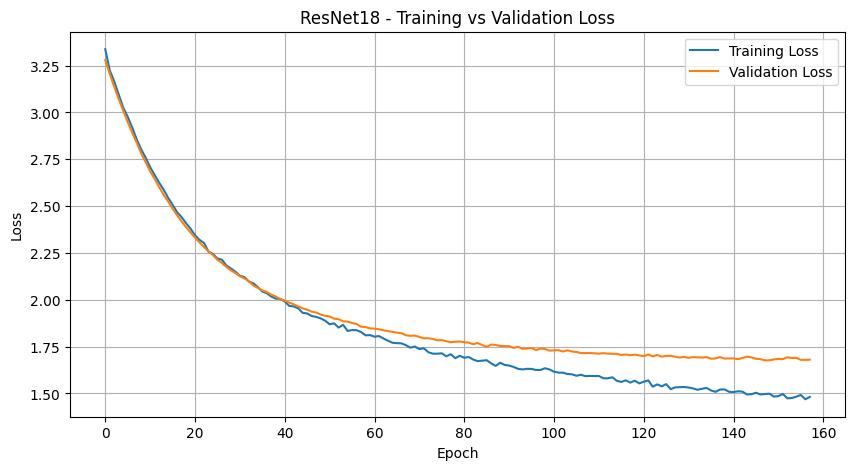

In [ ]:
import matplotlib.pyplot as plt

# =========================
# ResNet18 Loss Curve
# =========================

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 - Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

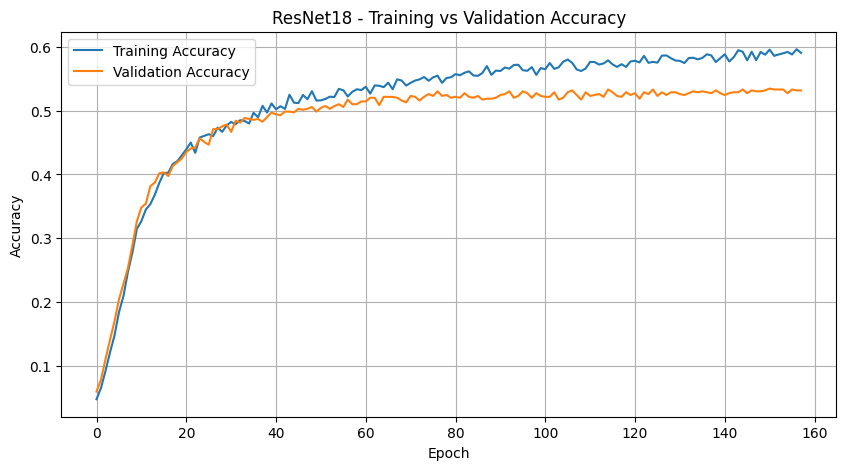

In [ ]:
# =========================
# ResNet18 Accuracy Curve
# =========================

plt.figure(figsize=(10, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Load the best ResNet18 checkpoint

best_model_path = "/content/best_resnet18_smartvision.pth"

model.load_state_dict(torch.load(
    best_model_path,
    map_location=device
))

model = model.to(device)

print("Best ResNet18 model loaded successfully!")

Best ResNet18 model loaded successfully!


In [ ]:
# ==========================================
# ResNet18 - Test Set Evaluation
# ==========================================

model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        # Predictions
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


# Calculate final metrics
test_loss = test_loss / total
test_accuracy = correct / total


print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 1.7556
Test Accuracy: 0.5021
Test Accuracy: 50.21%


In [ ]:
# Class names in the same order as the dataset
class_names = [
    'airplane',
    'bed',
    'bench',
    'bicycle',
    'bird',
    'bottle',
    'bowl',
    'bus',
    'cake',
    'car',
    'cat',
    'chair',
    'couch',
    'cow',
    'cup',
    'dog',
    'elephant',
    'horse',
    'motorcycle',
    'person',
    'pizza',
    'potted plant',
    'stop sign',
    'traffic light',
    'train',
    'truck'
]

print("Number of classes:", len(class_names))
print(class_names)

Number of classes: 26
['airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle', 'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch', 'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle', 'person', 'pizza', 'potted plant', 'stop sign', 'traffic light', 'train', 'truck']


In [ ]:
from sklearn.metrics import classification_report

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())


report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print(report)

               precision    recall  f1-score   support

     airplane     0.8667    0.8125    0.8387        32
          bed     0.5000    0.4348    0.4651        46
        bench     0.3500    0.2333    0.2800        30
      bicycle     0.3103    0.3913    0.3462        23
         bird     0.4500    0.5625    0.5000        16
       bottle     0.1579    0.1500    0.1538        20
         bowl     0.3667    0.3929    0.3793        28
          bus     0.6111    0.6111    0.6111        36
         cake     0.4138    0.5217    0.4615        23
          car     0.1304    0.2000    0.1579        15
          cat     0.6744    0.6042    0.6374        48
        chair     0.0741    0.1176    0.0909        17
        couch     0.4074    0.2558    0.3143        43
          cow     0.6875    0.6875    0.6875        16
          cup     0.1613    0.1923    0.1754        26
          dog     0.4516    0.3684    0.4058        38
     elephant     0.8636    0.8636    0.8636        22
        h

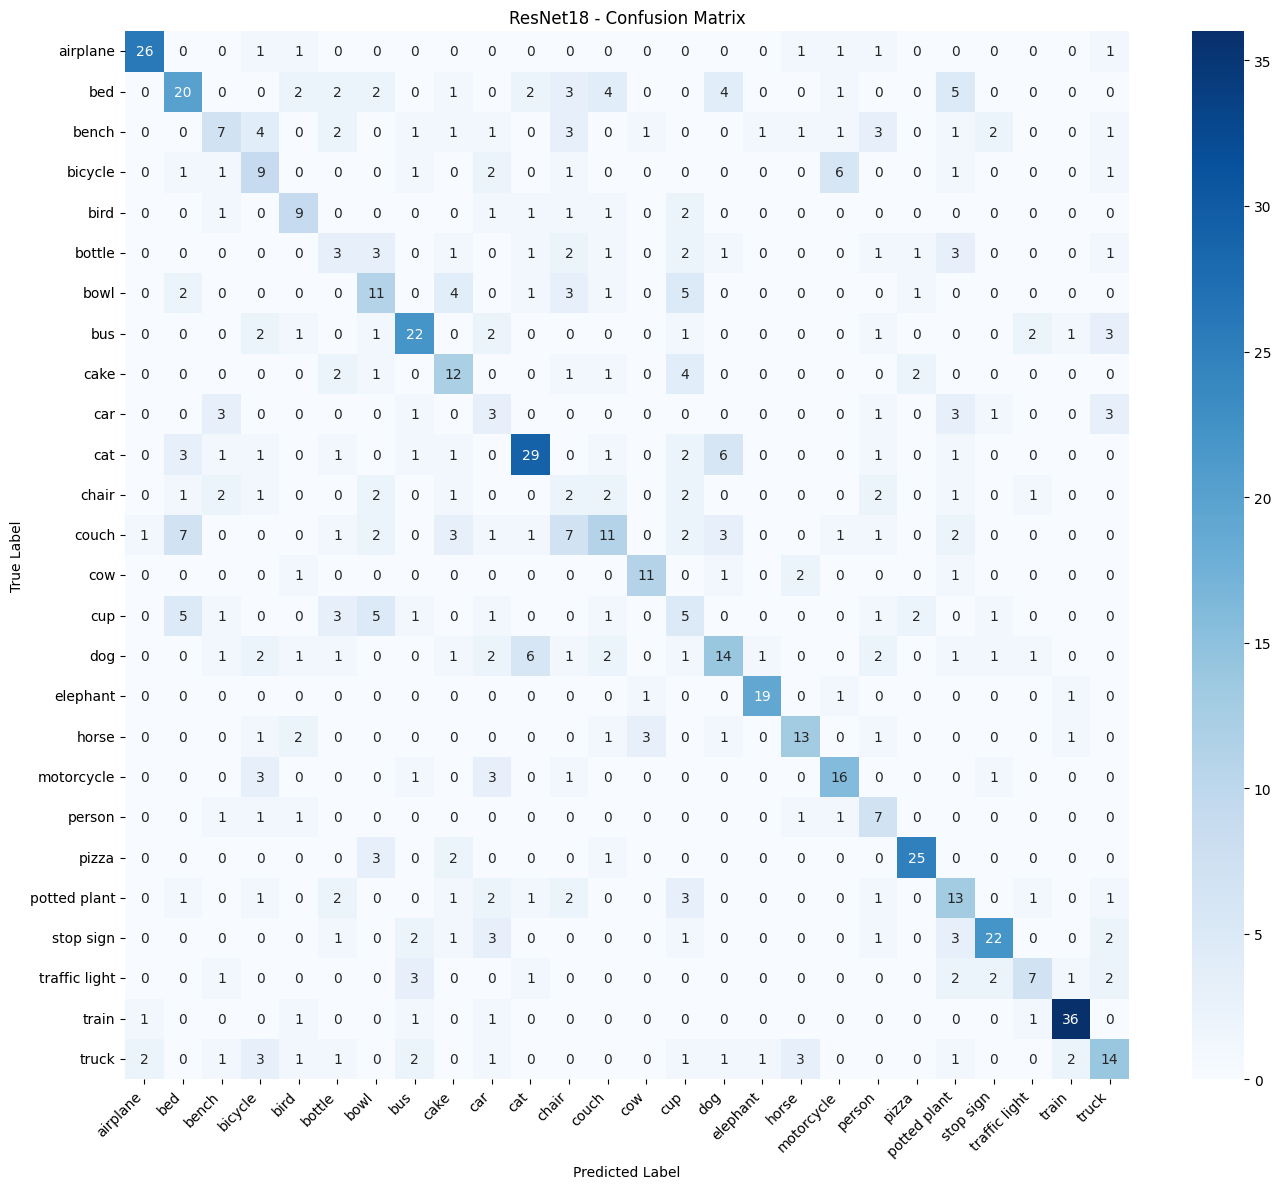

In [ ]:
# confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet18 - Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# ResNet18 — Experiment 2
# Fresh model
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

# Create a fresh ResNet18
model_exp2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the final classification layer
num_features = model_exp2.fc.in_features

model_exp2.fc = nn.Linear(
    num_features,
    len(class_names)
)

# Move model to GPU
model_exp2 = model_exp2.to(device)

print(model_exp2.fc)

Linear(in_features=512, out_features=26, bias=True)


In [ ]:
# ============================================================
# ResNet18 Experiment 2 — Freeze Backbone
# ============================================================

# Freeze all pretrained layers
for param in model_exp2.parameters():
    param.requires_grad = False

# Unfreeze only the final classification layer
for param in model_exp2.fc.parameters():
    param.requires_grad = True

# Check parameters
total_params = sum(p.numel() for p in model_exp2.parameters())
trainable_params = sum(
    p.numel() for p in model_exp2.parameters()
    if p.requires_grad
)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

Total parameters: 11189850
Trainable parameters: 13338


In [ ]:
# ============================================================
# ResNet18 Experiment 2 — Loss Function & Optimizer
# ============================================================

criterion_exp2 = nn.CrossEntropyLoss()

optimizer_exp2 = torch.optim.Adam(
    model_exp2.fc.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print("Loss function:", criterion_exp2)
print("Optimizer:", optimizer_exp2)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
# ============================================================
# ResNet18 Experiment 2 — Training Loop
# ============================================================

# Training configuration

MAX_EPOCHS = 200
PATIENCE = 10

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "resnet18_exp2_best.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: resnet18_exp2_best.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("resnet18_exp2_best.pth")

print("✅ Download requested successfully!")

Epoch [1/200] | Train Loss: 1.4893 | Train Acc: 0.5879 | Val Loss: 1.6819 | Val Acc: 0.5332 | ✓ Best model saved
Epoch [2/200] | Train Loss: 1.4989 | Train Acc: 0.5882 | Val Loss: 1.6839 | Val Acc: 0.5318 | Patience: 1/10
Epoch [3/200] | Train Loss: 1.4777 | Train Acc: 0.5995 | Val Loss: 1.6842 | Val Acc: 0.5318 | Patience: 2/10
Epoch [4/200] | Train Loss: 1.4853 | Train Acc: 0.5900 | Val Loss: 1.6858 | Val Acc: 0.5318 | Patience: 3/10
Epoch [5/200] | Train Loss: 1.4868 | Train Acc: 0.6034 | Val Loss: 1.6919 | Val Acc: 0.5332 | Patience: 4/10
Epoch [6/200] | Train Loss: 1.4887 | Train Acc: 0.5857 | Val Loss: 1.6842 | Val Acc: 0.5275 | Patience: 5/10
Epoch [7/200] | Train Loss: 1.4910 | Train Acc: 0.5909 | Val Loss: 1.6868 | Val Acc: 0.5361 | Patience: 6/10
Epoch [8/200] | Train Loss: 1.4803 | Train Acc: 0.5937 | Val Loss: 1.6838 | Val Acc: 0.5289 | Patience: 7/10
Epoch [9/200] | Train Loss: 1.4747 | Train Acc: 0.6004 | Val Loss: 1.6786 | Val Acc: 0.5332 | ✓ Best model saved
Epoch [10/2

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download requested successfully!


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source = "/content/resnet18_exp2_best.pth"
destination = "/content/drive/MyDrive/resnet18_exp2_best.pth"

shutil.copy2(source, destination)

print("✅ Model copied to Google Drive!")
print(f"📁 {destination}")
print(f"📦 Size: {os.path.getsize(source) / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive!
📁 /content/drive/MyDrive/resnet18_exp2_best.pth
📦 Size: 42.76 MB


In [ ]:
import matplotlib.pyplot as plt

# ============================================================
# ResNet18 Experiment 2 — Training Curves
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(train_losses_exp2, label="Train Loss")
plt.plot(val_losses_exp2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Experiment 2 - Loss Curve")
plt.legend()
plt.grid(True)

plt.show()

NameError: name 'train_losses_exp2' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_accs_exp2, label="Train Accuracy")
plt.plot(val_accs_exp2, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet18 Experiment 2 - Accuracy Curve")
plt.legend()
plt.grid(True)

plt.show()

NameError: name 'train_accs_exp2' is not defined

<Figure size 800x500 with 0 Axes>

In [ ]:
# Load best ResNet18 Experiment 2 model
model.load_state_dict(
    torch.load("resnet18_exp2_best.pth", map_location=device)
)

model.to(device)
model.eval()

print("Best Experiment 2 model loaded.")

In [ ]:
test_loss = 0.0
correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)

        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())


test_loss = test_loss / total
test_accuracy = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

In [ ]:
from sklearn.metrics import classification_report

class_names = [
    'airplane', 'bed', 'bench', 'bicycle', 'bird', 'bottle',
    'bowl', 'bus', 'cake', 'car', 'cat', 'chair', 'couch',
    'cow', 'cup', 'dog', 'elephant', 'horse', 'motorcycle',
    'person', 'pizza', 'potted plant', 'stop sign',
    'traffic light', 'train', 'truck'
]

print(classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet18 Experiment 2 - Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# load MObileNet

from torchvision import models

model = models.mobilenet_v2(weights="DEFAULT")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 140MB/s]


In [ ]:
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    26
)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=26, bias=True)
)


In [ ]:
# Check parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 2257178
Trainable parameters: 2257178


In [ ]:
# Loss function + optimizer
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001,
    weight_decay=0.0001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
model = model.to(device)

print("Model device:", next(model.parameters()).device)

Model device: cuda:0


In [ ]:
images, labels = next(iter(train_loader))

print("Images:", images.device)
print("Model:", next(model.parameters()).device)

Images: cpu
Model: cuda:0


In [ ]:
# ============================================================
# MObile net v2
# ============================================================

# Training configuration

MAX_EPOCHS = 200
PATIENCE = 10

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "mobilenet_v2_best.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: mobilenet_v2_best.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("mobilenet_v2_best.pth")

print("✅ Download requested successfully!")

Epoch [1/200] | Train Loss: 3.1067 | Train Acc: 0.1818 | Val Loss: 2.9006 | Val Acc: 0.3309 | ✓ Best model saved
Epoch [2/200] | Train Loss: 2.6147 | Train Acc: 0.3545 | Val Loss: 2.3209 | Val Acc: 0.4133 | ✓ Best model saved
Epoch [3/200] | Train Loss: 2.1231 | Train Acc: 0.4512 | Val Loss: 1.9408 | Val Acc: 0.4827 | ✓ Best model saved
Epoch [4/200] | Train Loss: 1.8205 | Train Acc: 0.5247 | Val Loss: 1.6980 | Val Acc: 0.5390 | ✓ Best model saved
Epoch [5/200] | Train Loss: 1.6056 | Train Acc: 0.5757 | Val Loss: 1.5539 | Val Acc: 0.5766 | ✓ Best model saved
Epoch [6/200] | Train Loss: 1.4181 | Train Acc: 0.6147 | Val Loss: 1.4267 | Val Acc: 0.6156 | ✓ Best model saved
Epoch [7/200] | Train Loss: 1.2903 | Train Acc: 0.6473 | Val Loss: 1.3457 | Val Acc: 0.6199 | ✓ Best model saved
Epoch [8/200] | Train Loss: 1.1657 | Train Acc: 0.6763 | Val Loss: 1.2927 | Val Acc: 0.6243 | ✓ Best model saved
Epoch [9/200] | Train Loss: 1.0520 | Train Acc: 0.7026 | Val Loss: 1.2623 | Val Acc: 0.6387 | ✓ 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download requested successfully!


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source = "/content/mobilenet_v2_best.pth"
destination = "/content/drive/MyDrive/mobilenet_v2_best.pth"

shutil.copy2(source, destination)

print("✅ Model copied to Google Drive!")
print(f"📁 {destination}")
print(f"📦 Size: {os.path.getsize(source) / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive!
📁 /content/drive/MyDrive/mobilenet_v2_best.pth
📦 Size: 8.85 MB


In [ ]:
model.load_state_dict(
    torch.load("mobilenet_v2_best.pth", map_location=device)
)

model.to(device)
model.eval()

print("Best MobileNetV2 model loaded.")

Best MobileNetV2 model loaded.


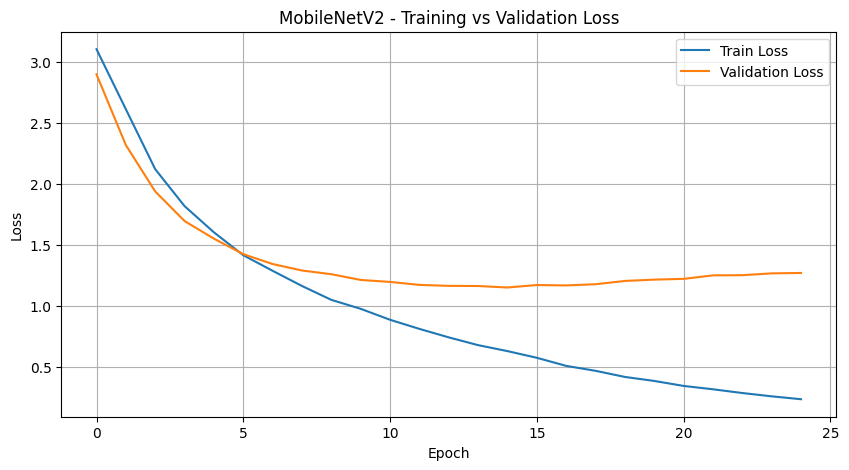

In [ ]:
# Plot Training and Validation Loss

plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MobileNetV2 - Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

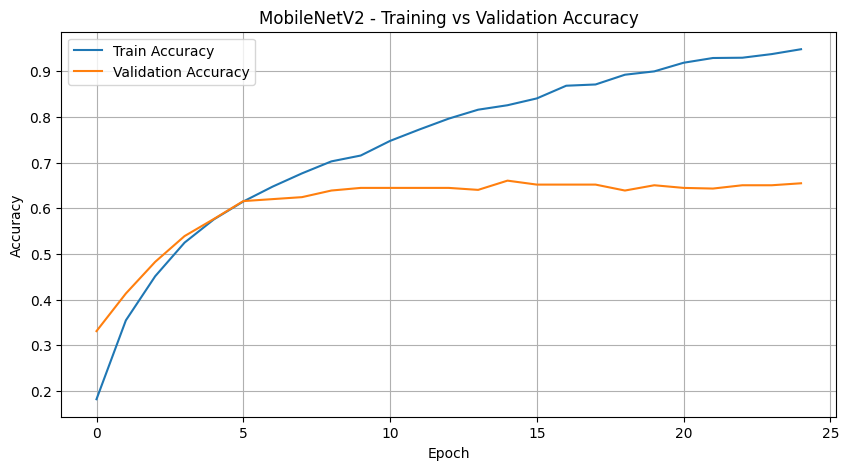

In [ ]:
# Plot Training and Validation Accuracy

plt.figure(figsize=(10, 5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNetV2 - Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
def evaluate_model(model, data_loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in data_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_loss = running_loss / total
    test_accuracy = correct / total

    return test_loss, test_accuracy

In [ ]:
test_loss, test_accuracy = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 1.2057
Test Accuracy: 0.6447
Test Accuracy: 64.47%


In [ ]:
from sklearn.metrics import classification_report

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())


print(classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4,
    zero_division=0
))

NameError: name 'class_names' is not defined

In [ ]:
# confusiion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 - Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

NameError: name 'class_names' is not defined

<Figure size 1400x1200 with 0 Axes>

In [ ]:
# MobileNetV2 — Experiment 2

import torch
import torch.nn as nn
from torchvision import models

# Load pretrained MobileNetV2
model = models.mobilenet_v2(weights="DEFAULT")

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier with stronger dropout
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(
        model.classifier[1].in_features,
        26
    )
)

# Move model to device
model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=1280, out_features=26, bias=True)
)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 2257178
Trainable parameters: 33306


In [ ]:
# Loss Function + Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.classifier.parameters(),
    lr=0.0001,
    weight_decay=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.001
)


In [ ]:
# ============================================================
# MObile net v2 exp 2
# ============================================================

# Training configuration

MAX_EPOCHS = 200
PATIENCE = 20

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "mobilenetv2_exp2_best.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: mobilenetv2_exp2_best.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("mobilenetv2_exp2_best.pth")

print("✅ Download requested successfully!")

Epoch [1/200] | Train Loss: 3.2420 | Train Acc: 0.0555 | Val Loss: 3.1695 | Val Acc: 0.1156 | ✓ Best model saved
Epoch [2/200] | Train Loss: 3.1452 | Train Acc: 0.1007 | Val Loss: 3.0841 | Val Acc: 0.1749 | ✓ Best model saved
Epoch [3/200] | Train Loss: 3.0721 | Train Acc: 0.1358 | Val Loss: 3.0125 | Val Acc: 0.2153 | ✓ Best model saved
Epoch [4/200] | Train Loss: 3.0054 | Train Acc: 0.1760 | Val Loss: 2.9484 | Val Acc: 0.2486 | ✓ Best model saved
Epoch [5/200] | Train Loss: 2.9323 | Train Acc: 0.2129 | Val Loss: 2.8869 | Val Acc: 0.3035 | ✓ Best model saved
Epoch [6/200] | Train Loss: 2.8677 | Train Acc: 0.2633 | Val Loss: 2.8245 | Val Acc: 0.3367 | ✓ Best model saved
Epoch [7/200] | Train Loss: 2.8099 | Train Acc: 0.2947 | Val Loss: 2.7702 | Val Acc: 0.3656 | ✓ Best model saved
Epoch [8/200] | Train Loss: 2.7575 | Train Acc: 0.3200 | Val Loss: 2.7151 | Val Acc: 0.3714 | ✓ Best model saved
Epoch [9/200] | Train Loss: 2.7022 | Train Acc: 0.3417 | Val Loss: 2.6655 | Val Acc: 0.3945 | ✓ 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download requested successfully!


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source = "/content/mobilenetv2_exp2_best.pth"
destination = "/content/drive/MyDrive/mobilenetv2_exp2_best.pth"

shutil.copy2(source, destination)

print("✅ Model copied to Google Drive!")
print(f"📁 {destination}")
print(f"📦 Size: {os.path.getsize(source) / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive!
📁 /content/drive/MyDrive/mobilenetv2_exp2_best.pth
📦 Size: 8.85 MB


In [ ]:
# tuning further

import torch
import torch.nn as nn
from torchvision import models

# Load pretrained MobileNetV2
model = models.mobilenet_v2(weights="DEFAULT")

# Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze the last few feature blocks
for param in model.features[-4:].parameters():
    param.requires_grad = True

# Replace classifier for our 26 classes
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(1280, 26)
)

# Make classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

# Move model to GPU
model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=1280, out_features=26, bias=True)
)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 2257178
Trainable parameters: 1559386


In [ ]:
# Loss Function + Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-3
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-05
    maximize: False
    weight_decay: 0.001
)


In [ ]:
# ============================================================
# MObile net v2 exp 3
# ============================================================

# Training configuration

MAX_EPOCHS = 200
PATIENCE = 20

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "mobilenetv2_exp3_best.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: mobilenetv2_exp3_best.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("mobilenetv2_exp3_best.pth")

print("✅ Download requested successfully!")

Epoch [1/200] | Train Loss: 3.2660 | Train Acc: 0.0451 | Val Loss: 3.2400 | Val Acc: 0.0723 | ✓ Best model saved
Epoch [2/200] | Train Loss: 3.2404 | Train Acc: 0.0580 | Val Loss: 3.2131 | Val Acc: 0.0824 | ✓ Best model saved
Epoch [3/200] | Train Loss: 3.2166 | Train Acc: 0.0677 | Val Loss: 3.1860 | Val Acc: 0.1142 | ✓ Best model saved
Epoch [4/200] | Train Loss: 3.1864 | Train Acc: 0.0894 | Val Loss: 3.1572 | Val Acc: 0.1402 | ✓ Best model saved
Epoch [5/200] | Train Loss: 3.1584 | Train Acc: 0.1107 | Val Loss: 3.1301 | Val Acc: 0.1821 | ✓ Best model saved
Epoch [6/200] | Train Loss: 3.1278 | Train Acc: 0.1370 | Val Loss: 3.0993 | Val Acc: 0.2182 | ✓ Best model saved
Epoch [7/200] | Train Loss: 3.0982 | Train Acc: 0.1632 | Val Loss: 3.0671 | Val Acc: 0.2514 | ✓ Best model saved
Epoch [8/200] | Train Loss: 3.0654 | Train Acc: 0.1815 | Val Loss: 3.0326 | Val Acc: 0.2847 | ✓ Best model saved
Epoch [9/200] | Train Loss: 3.0306 | Train Acc: 0.2148 | Val Loss: 2.9962 | Val Acc: 0.2962 | ✓ 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download requested successfully!


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source = "/content/mobilenetv2_exp3_best.pth"
destination = "/content/drive/MyDrive/mobilenetv2_exp3_best.pth"

shutil.copy2(source, destination)

print("✅ Model copied to Google Drive!")
print(f"📁 {destination}")
print(f"📦 Size: {os.path.getsize(source) / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive!
📁 /content/drive/MyDrive/mobilenetv2_exp3_best.pth
📦 Size: 8.85 MB


In [ ]:
# lets do exp 4

# Freeze the entire MobileNetV2 backbone
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze the LAST 7 feature blocks
for param in model.features[-7:].parameters():
    param.requires_grad = True

# Keep classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 2257178
Trainable parameters: 1951194


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
    weight_decay=1e-3
)

In [ ]:
# ============================================================
# MObile net v2 exp 4
# ============================================================

# Training configuration

MAX_EPOCHS = 200
PATIENCE = 20

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "mobilenetv2_exp4_best.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: mobilenetv2_exp4_best.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("mobilenetv2_exp4_best.pth")

print("✅ Download requested successfully!")

Epoch [1/200] | Train Loss: 0.8488 | Train Acc: 0.7611 | Val Loss: 1.2335 | Val Acc: 0.6286 | ✓ Best model saved
Epoch [2/200] | Train Loss: 0.8247 | Train Acc: 0.7642 | Val Loss: 1.2324 | Val Acc: 0.6243 | ✓ Best model saved
Epoch [3/200] | Train Loss: 0.8257 | Train Acc: 0.7578 | Val Loss: 1.2315 | Val Acc: 0.6214 | ✓ Best model saved
Epoch [4/200] | Train Loss: 0.8211 | Train Acc: 0.7614 | Val Loss: 1.2312 | Val Acc: 0.6301 | ✓ Best model saved
Epoch [5/200] | Train Loss: 0.8126 | Train Acc: 0.7660 | Val Loss: 1.2313 | Val Acc: 0.6272 | Patience: 1/20
Epoch [6/200] | Train Loss: 0.8074 | Train Acc: 0.7678 | Val Loss: 1.2341 | Val Acc: 0.6228 | Patience: 2/20
Epoch [7/200] | Train Loss: 0.8071 | Train Acc: 0.7685 | Val Loss: 1.2313 | Val Acc: 0.6315 | Patience: 3/20
Epoch [8/200] | Train Loss: 0.8137 | Train Acc: 0.7611 | Val Loss: 1.2276 | Val Acc: 0.6286 | ✓ Best model saved
Epoch [9/200] | Train Loss: 0.7928 | Train Acc: 0.7672 | Val Loss: 1.2368 | Val Acc: 0.6286 | Patience: 1/20

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download requested successfully!


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source = "/content/mobilenetv2_exp4_best.pth"
destination = "/content/drive/MyDrive/mobilenetv2_exp4_best.pth"

shutil.copy2(source, destination)

print("✅ Model copied to Google Drive!")
print(f"📁 {destination}")
print(f"📦 Size: {os.path.getsize(source) / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive!
📁 /content/drive/MyDrive/mobilenetv2_exp4_best.pth
📦 Size: 8.85 MB


In [ ]:
# lets do exp 5

# Freeze the entire MobileNetV2 backbone
for param in model.features.parameters():
    param.requires_grad = False

# Unfreeze the LAST 7 feature blocks
for param in model.features[-7:].parameters():
    param.requires_grad = True

# Keep classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

In [ ]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 2257178
Trainable parameters: 1951194


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-6,
    weight_decay=1e-3
)

In [ ]:
# ============================================================
# MObile net v2 exp 5
# ============================================================

# Training configuration

MAX_EPOCHS = 200
PATIENCE = 20

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "mobilenetv2_exp5_best.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: mobilenetv2_exp5_best.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("mobilenetv2_exp5_best.pth")

print("✅ Download requested successfully!")

Epoch [1/200] | Train Loss: 0.6759 | Train Acc: 0.8093 | Val Loss: 1.2305 | Val Acc: 0.6344 | ✓ Best model saved
Epoch [2/200] | Train Loss: 0.6756 | Train Acc: 0.8096 | Val Loss: 1.2375 | Val Acc: 0.6301 | Patience: 1/20
Epoch [3/200] | Train Loss: 0.6634 | Train Acc: 0.8139 | Val Loss: 1.2350 | Val Acc: 0.6329 | Patience: 2/20
Epoch [4/200] | Train Loss: 0.6675 | Train Acc: 0.8154 | Val Loss: 1.2281 | Val Acc: 0.6373 | ✓ Best model saved
Epoch [5/200] | Train Loss: 0.6672 | Train Acc: 0.8157 | Val Loss: 1.2318 | Val Acc: 0.6373 | Patience: 1/20
Epoch [6/200] | Train Loss: 0.6749 | Train Acc: 0.8139 | Val Loss: 1.2313 | Val Acc: 0.6373 | Patience: 2/20
Epoch [7/200] | Train Loss: 0.6652 | Train Acc: 0.8130 | Val Loss: 1.2290 | Val Acc: 0.6358 | Patience: 3/20
Epoch [8/200] | Train Loss: 0.6633 | Train Acc: 0.8115 | Val Loss: 1.2307 | Val Acc: 0.6301 | Patience: 4/20
Epoch [9/200] | Train Loss: 0.6540 | Train Acc: 0.8139 | Val Loss: 1.2312 | Val Acc: 0.6329 | Patience: 5/20
Epoch [10/2

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download requested successfully!


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source = "/content/mobilenetv2_exp5_best.pth"
destination = "/content/drive/MyDrive/mobilenetv2_exp5_best.pth"

shutil.copy2(source, destination)

print("✅ Model copied to Google Drive!")
print(f"📁 {destination}")
print(f"📦 Size: {os.path.getsize(source) / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive!
📁 /content/drive/MyDrive/mobilenetv2_exp5_best.pth
📦 Size: 8.85 MB


In [ ]:
model.load_state_dict(
    torch.load(
        "mobilenetv2_exp5_best.pth",
        map_location=device
    )
)

model = model.to(device)

In [ ]:
test_loss, test_accuracy = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 1.2270
Test Accuracy: 0.6104
Test Accuracy: 61.04%


In [ ]:
# EfficientNet

import torch
import torch.nn as nn
from torchvision import models

# Load pretrained EfficientNet-B0
model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Number of classes
num_classes = 26

# Replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(
        model.classifier[1].in_features,
        num_classes
    )
)

# Move model to GPU/CPU
model = model.to(device)

print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 117MB/s] 


Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=26, bias=True)
)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 4040854
Trainable parameters: 4040854


In [ ]:
# loss function + optimizer


criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)


Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
# ============================================================
# Efficient net  exp 1
# ============================================================

# Training configuration

MAX_EPOCHS = 200
PATIENCE = 20

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "EfficientNet_exp_1.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: EfficientNet_exp_1.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("EfficientNet_exp_1.pth")

print("✅ Download requested successfully!")

Epoch [1/200] | Train Loss: 3.0969 | Train Acc: 0.1681 | Val Loss: 2.8403 | Val Acc: 0.3598 | ✓ Best model saved
Epoch [2/200] | Train Loss: 2.5755 | Train Acc: 0.3755 | Val Loss: 2.2343 | Val Acc: 0.4234 | ✓ Best model saved
Epoch [3/200] | Train Loss: 2.0915 | Train Acc: 0.4658 | Val Loss: 1.8481 | Val Acc: 0.5072 | ✓ Best model saved
Epoch [4/200] | Train Loss: 1.7690 | Train Acc: 0.5384 | Val Loss: 1.6353 | Val Acc: 0.5679 | ✓ Best model saved
Epoch [5/200] | Train Loss: 1.5270 | Train Acc: 0.5949 | Val Loss: 1.4712 | Val Acc: 0.6026 | ✓ Best model saved
Epoch [6/200] | Train Loss: 1.3292 | Train Acc: 0.6358 | Val Loss: 1.3655 | Val Acc: 0.6127 | ✓ Best model saved
Epoch [7/200] | Train Loss: 1.1723 | Train Acc: 0.6656 | Val Loss: 1.2857 | Val Acc: 0.6344 | ✓ Best model saved
Epoch [8/200] | Train Loss: 1.0446 | Train Acc: 0.7032 | Val Loss: 1.2389 | Val Acc: 0.6387 | ✓ Best model saved
Epoch [9/200] | Train Loss: 0.9246 | Train Acc: 0.7312 | Val Loss: 1.2030 | Val Acc: 0.6488 | ✓ 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download requested successfully!


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source = "/content/EfficientNet_exp_1.pth"
destination = "/content/drive/MyDrive/EfficientNet_exp_1.pth"

shutil.copy2(source, destination)

print("✅ Model copied to Google Drive!")
print(f"📁 {destination}")
print(f"📦 Size: {os.path.getsize(source) / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive!
📁 /content/drive/MyDrive/EfficientNet_exp_1.pth
📦 Size: 15.70 MB


In [ ]:
# efficeint exp 2
from torchvision import models
import torch.nn as nn

model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.DEFAULT
)

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(
        model.classifier[1].in_features,
        26
    )
)

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=26, bias=True)
)


In [ ]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 4040854
Trainable parameters: 33306


In [ ]:
# Configure loss + optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [ ]:
# ============================================================
# Efficient net  exp 1
# ============================================================

# Training configuration

MAX_EPOCHS = 200
PATIENCE = 20

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "EfficientNet_exp_2.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: EfficientNet_exp_2.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("EfficientNet_exp_2.pth")

print("✅ Download requested successfully!")

Epoch [1/200] | Train Loss: 2.9249 | Train Acc: 0.2315 | Val Loss: 2.5623 | Val Acc: 0.4118 | ✓ Best model saved
Epoch [2/200] | Train Loss: 2.3651 | Train Acc: 0.4170 | Val Loss: 2.1703 | Val Acc: 0.4754 | ✓ Best model saved
Epoch [3/200] | Train Loss: 2.0509 | Train Acc: 0.4780 | Val Loss: 1.9539 | Val Acc: 0.4971 | ✓ Best model saved
Epoch [4/200] | Train Loss: 1.8778 | Train Acc: 0.5156 | Val Loss: 1.8331 | Val Acc: 0.5043 | ✓ Best model saved
Epoch [5/200] | Train Loss: 1.7757 | Train Acc: 0.5217 | Val Loss: 1.7562 | Val Acc: 0.5173 | ✓ Best model saved
Epoch [6/200] | Train Loss: 1.6776 | Train Acc: 0.5415 | Val Loss: 1.7103 | Val Acc: 0.5173 | ✓ Best model saved
Epoch [7/200] | Train Loss: 1.6219 | Train Acc: 0.5500 | Val Loss: 1.6664 | Val Acc: 0.5246 | ✓ Best model saved
Epoch [8/200] | Train Loss: 1.5714 | Train Acc: 0.5601 | Val Loss: 1.6370 | Val Acc: 0.5275 | ✓ Best model saved
Epoch [9/200] | Train Loss: 1.5044 | Train Acc: 0.5869 | Val Loss: 1.6220 | Val Acc: 0.5275 | ✓ 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download requested successfully!


In [ ]:
from google.colab import drive
import shutil
import os

drive.mount('/content/drive')

source = "/content/EfficientNet_exp_2.pth"
destination = "/content/drive/MyDrive/EfficientNet_exp_2.pth"

shutil.copy2(source, destination)

print("✅ Model copied to Google Drive!")
print(f"📁 {destination}")
print(f"📦 Size: {os.path.getsize(source) / (1024**2):.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Model copied to Google Drive!
📁 /content/drive/MyDrive/EfficientNet_exp_2.pth
📦 Size: 15.70 MB


In [ ]:
from collections import Counter

print("Train:")
print(Counter(train_dataset.targets))

print("\nValidation:")
print(Counter(val_dataset.targets))

print("\nTest:")
print(Counter(test_dataset.targets))

Train:
Counter({10: 218, 1: 212, 12: 195, 24: 189, 15: 174, 22: 163, 7: 161, 25: 156, 0: 145, 20: 137, 2: 133, 21: 132, 6: 125, 14: 115, 18: 110, 8: 104, 17: 103, 3: 102, 16: 100, 5: 88, 23: 85, 11: 72, 4: 69, 13: 68, 9: 66, 19: 56})

Validation:
Counter({10: 46, 1: 45, 12: 41, 24: 40, 15: 37, 7: 34, 22: 34, 25: 33, 0: 31, 20: 29, 2: 28, 21: 28, 6: 26, 14: 24, 18: 23, 3: 22, 8: 22, 17: 22, 16: 21, 5: 19, 23: 18, 11: 15, 4: 14, 9: 14, 13: 14, 19: 12})

Test:
Counter({10: 48, 1: 46, 12: 43, 24: 41, 15: 38, 7: 36, 22: 36, 25: 34, 0: 32, 20: 31, 2: 30, 21: 29, 6: 28, 14: 26, 18: 25, 3: 23, 8: 23, 17: 23, 16: 22, 5: 20, 23: 19, 11: 17, 4: 16, 13: 16, 9: 15, 19: 12})


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

In [ ]:
# ============================================================
# Efficient net  exp 1
# ============================================================

# Training configuration

MAX_EPOCHS = 200
PATIENCE = 20

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(MAX_EPOCHS):

    # =========================
    # Training
    # =========================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_accuracy = correct / total


    # =========================
    # Validation
    # =========================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total


    # =========================
    # Store metrics
    # =========================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # =========================
    # Early stopping
    # =========================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            model.state_dict(),
            "EfficientNet_exp_1.pth"
        )

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"✓ Best model saved"
        )

    else:

        patience_counter += 1

        print(
            f"Epoch [{epoch + 1}/{MAX_EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Patience: {patience_counter}/{PATIENCE}"
        )


    # Stop if validation loss has not improved
    if patience_counter >= PATIENCE:

        print("\nEarly stopping triggered.")
        print(f"Training stopped at epoch {epoch + 1}.")
        break


# ============================================================
# AUTOMATICALLY DOWNLOAD BEST MODEL AFTER TRAINING ENDS
# ============================================================

from google.colab import files

print("\n" + "=" * 60)
print("🎉 TRAINING LOOP FINISHED!")
print("=" * 60)

print("📁 Best model: EfficientNet_exp_3.pth")
print(f"📉 Best validation loss: {best_val_loss:.4f}")

print("\n⬇️ Starting automatic download...")

files.download("EfficientNet_exp_1.pth")

print("✅ Download requested successfully!")

### 3.11 EfficientNet Experiment 3: Refined Hyperparameters and Learning Rate Scheduler

To further improve the performance of the EfficientNetB0 model and address potential overfitting, this experiment will focus on a more refined hyperparameter tuning approach, specifically by introducing a learning rate scheduler. A scheduler dynamically adjusts the learning rate during training, which can lead to better convergence and generalization.

We will also consider using class weights to handle the imbalanced dataset, as observed previously.

In [29]:
import torch
import torch.nn as nn
from torchvision import models

MODEL_PATH = "/content/drive/MyDrive/EfficientNet_exp_1.pth"

# Load EfficientNet-B0 architecture
model = models.efficientnet_b0(weights=None)

# Replace classifier for our 26 classes
num_classes = 26

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

# Load our trained weights
model.load_state_dict(
    torch.load(MODEL_PATH, map_location=device)
)

# Move model to device
model = model.to(device)

# Evaluation mode
model.eval()

print("✅ EfficientNetB0 Exp 1 loaded successfully!")
print("📁 Model:", MODEL_PATH)
print("🔢 Number of classes:", num_classes)
print("⚡ Device:", device)

✅ EfficientNetB0 Exp 1 loaded successfully!
📁 Model: /content/drive/MyDrive/EfficientNet_exp_1.pth
🔢 Number of classes: 26
⚡ Device: cuda


In [30]:
print("test_dataset exists:", "test_dataset" in globals())
print("test_loader exists:", "test_loader" in globals())

test_dataset exists: True
test_loader exists: True


In [31]:
# ============================================
# TEST SET EVALUATION
# ============================================

import torch

model.eval()

test_correct = 0
test_total = 0
test_running_loss = 0.0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()


test_loss = test_running_loss / test_total
test_accuracy = test_correct / test_total


print("=" * 60)
print("🧪 TEST SET EVALUATION")
print("=" * 60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

print("=" * 60)

🧪 TEST SET EVALUATION
Test Loss     : 1.3619
Test Accuracy : 0.6406
Test Accuracy : 64.06%


In [32]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

model.eval()

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())


print("=" * 70)
print("📊 CLASSIFICATION REPORT — EfficientNetB0 Exp 1")
print("=" * 70)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes,
        digits=4
    )
)

📊 CLASSIFICATION REPORT — EfficientNetB0 Exp 1
               precision    recall  f1-score   support

     airplane     0.9091    0.9375    0.9231        32
          bed     0.6667    0.6522    0.6593        46
        bench     0.5000    0.2333    0.3182        30
      bicycle     0.5769    0.6522    0.6122        23
         bird     1.0000    0.6250    0.7692        16
       bottle     0.4444    0.4000    0.4211        20
         bowl     0.5625    0.6429    0.6000        28
          bus     0.7273    0.6667    0.6957        36
         cake     0.7647    0.5652    0.6500        23
          car     0.0000    0.0000    0.0000        15
          cat     0.7451    0.7917    0.7677        48
        chair     0.0000    0.0000    0.0000        17
        couch     0.6053    0.5349    0.5679        43
          cow     0.8571    0.7500    0.8000        16
          cup     0.3030    0.3846    0.3390        26
          dog     0.6190    0.6842    0.6500        38
     elephant    

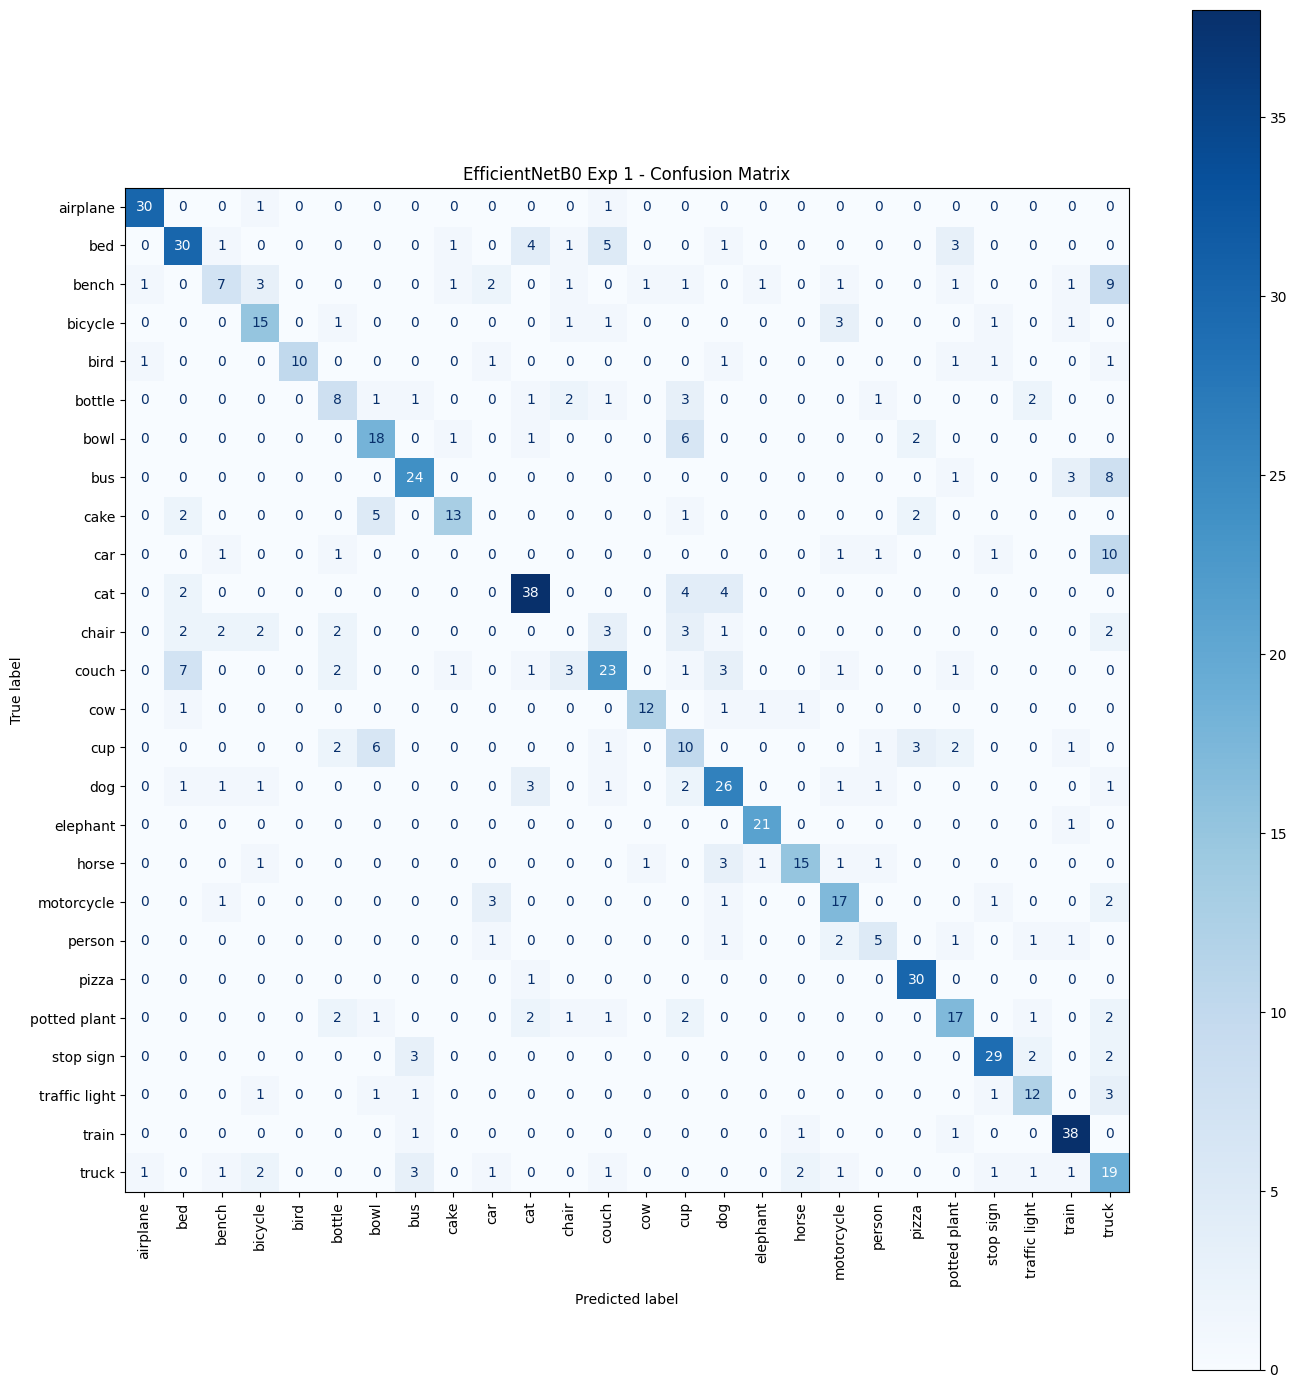

In [33]:
# ============================================
# CONFUSION MATRIX
# ============================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

fig, ax = plt.subplots(figsize=(14, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=test_dataset.classes
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues",
    colorbar=True
)

plt.title("EfficientNetB0 Exp 1 - Confusion Matrix")
plt.tight_layout()
plt.show()

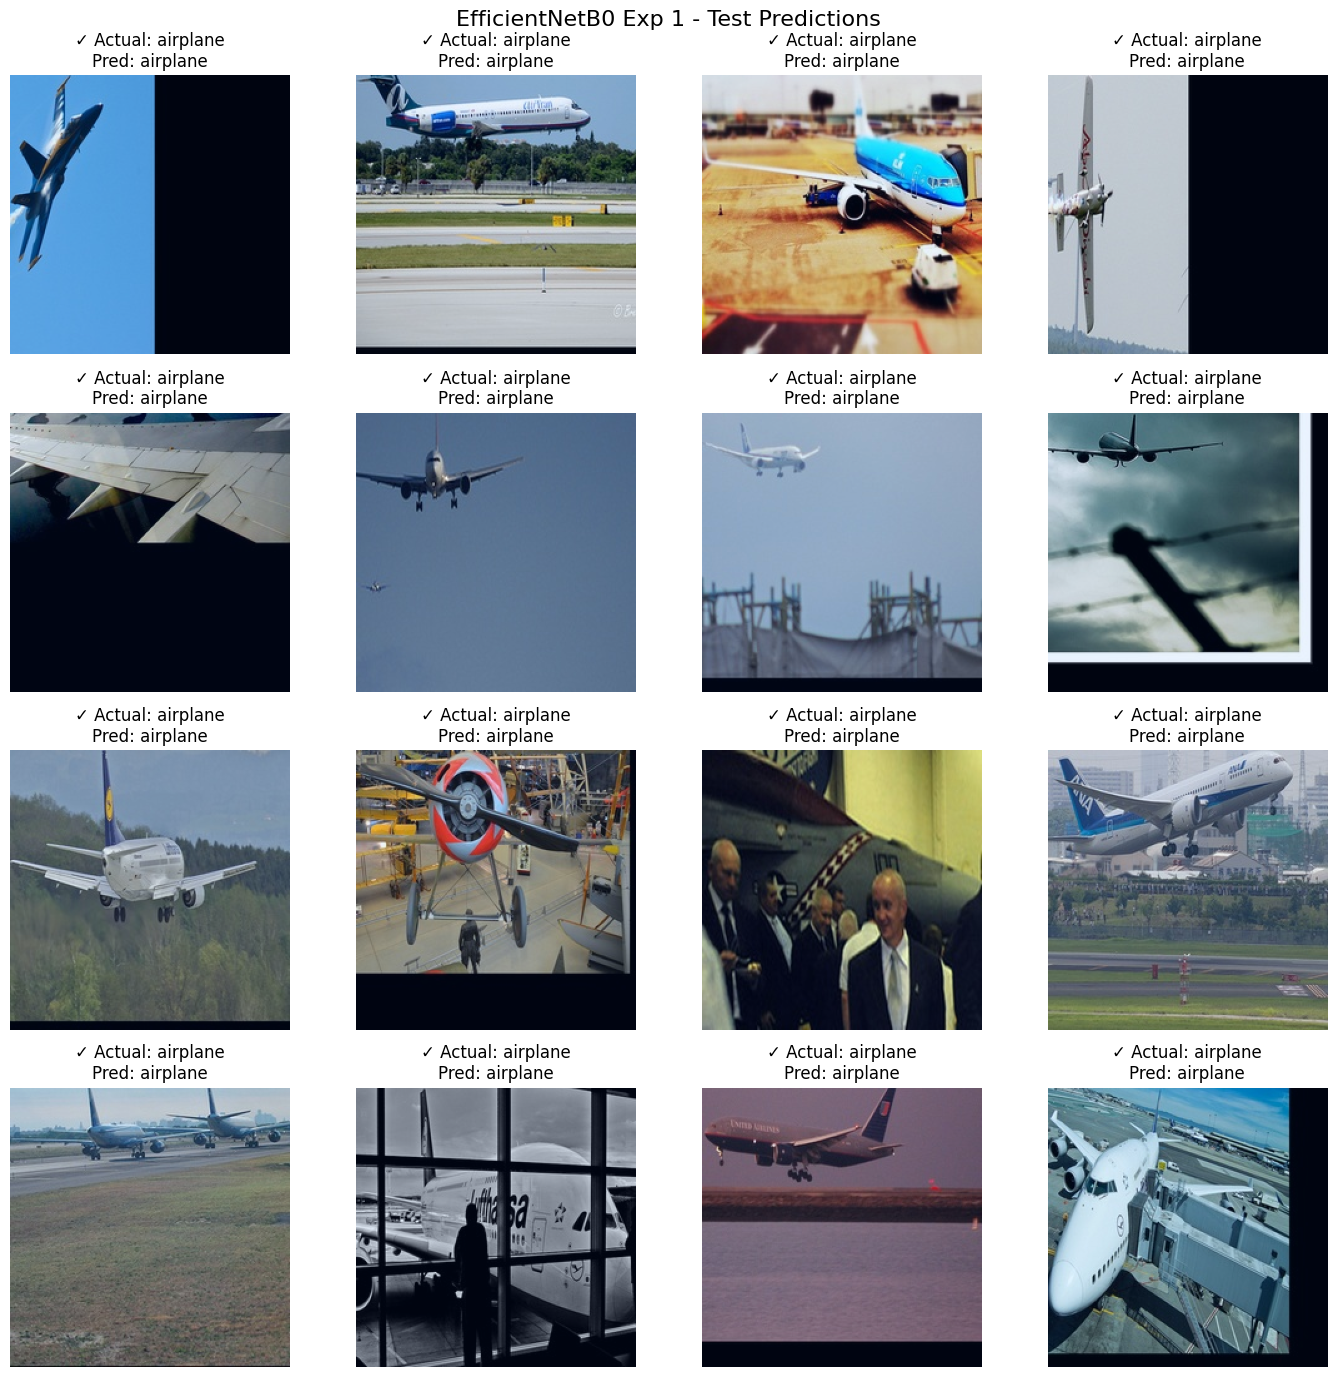

In [34]:
# ============================================
# VISUALIZE TEST PREDICTIONS
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

images_to_show = []
actual_labels = []
predicted_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        for i in range(images.size(0)):

            images_to_show.append(images[i].cpu())
            actual_labels.append(labels[i].item())
            predicted_labels.append(predictions[i].item())

            if len(images_to_show) >= 16:
                break

        if len(images_to_show) >= 16:
            break


# Display predictions
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for i, ax in enumerate(axes.flat):

    image = images_to_show[i].permute(1, 2, 0).numpy()

    # Normalize for visualization
    image = (image - image.min()) / (image.max() - image.min())

    actual = test_dataset.classes[actual_labels[i]]
    predicted = test_dataset.classes[predicted_labels[i]]

    ax.imshow(image)

    if actual_labels[i] == predicted_labels[i]:
        title = f"✓ Actual: {actual}\nPred: {predicted}"
    else:
        title = f"✗ Actual: {actual}\nPred: {predicted}"

    ax.set_title(title)
    ax.axis("off")

plt.suptitle(
    "EfficientNetB0 Exp 1 - Test Predictions",
    fontsize=16
)

plt.tight_layout()
plt.show()